# HW08-09: PyTorch MLP — регуляризация и оптимизация

Домашнее задание: MLP на KMNIST, эксперименты E1–E4 (регуляризация) и O1–O3 (LR, оптимизаторы).

## 1. Imports and Setup

In [1]:
%matplotlib inline
import os
import json
import random
import csv
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

ARTIFACTS = 'artifacts'
FIGURES = os.path.join(ARTIFACTS, 'figures')
os.makedirs(FIGURES, exist_ok=True)

SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 15
HIDDEN_DIMS = (256, 128)
NUM_CLASSES = 10
INPUT_DIM = 28 * 28

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def accuracy_from_logits(logits, y_true):
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

## 2. Data Loading (KMNIST)

In [2]:
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

# KMNIST: сервер codh.rois.ac.jp часто таймаутит — fallback на FashionMNIST
try:
    train_full = torchvision.datasets.KMNIST(root="./data", train=True, download=True, transform=transform)
    test_ds = torchvision.datasets.KMNIST(root="./data", train=False, download=True, transform=transform)
    dataset_name = "KMNIST"
except (RuntimeError, OSError):
    train_full = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
    test_ds = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
    dataset_name = "FashionMNIST"
    print("KMNIST недоступен (таймаут), используем FashionMNIST")
print(f"dataset: {dataset_name}")

val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size
gen = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [train_size, val_size], generator=gen)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

device: cpu
KMNIST недоступен (таймаут), используем FashionMNIST
dataset: FashionMNIST


## 3. MLP Model Definition

In [3]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(256, 128), num_classes=10,
                 dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(p=dropout_p))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## 4. EarlyStopping, train/eval, fit and plot_history

In [4]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0

    def step(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        if score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n += 1
    return total_loss / n, total_acc / n

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        total_acc += accuracy_from_logits(logits, y)
        n += 1
    return total_loss / n, total_acc / n

def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs,
        early_stopping=None, verbose=True):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        if verbose:
            print(f"epoch {epoch:02d}/{epochs} | train loss={tr_loss:.4f} acc={tr_acc:.4f} | val loss={va_loss:.4f} acc={va_acc:.4f}")
        if early_stopping is not None:
            if early_stopping.step(va_acc, model):
                early_stopping.restore_best(model)
                break
    return history

def plot_history(history, title="", savepath=None):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="train_loss")
    axes[0].plot(epochs, history["val_loss"], label="val_loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].set_title(f"{title} - loss")
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(epochs, history["train_acc"], label="train_acc")
    axes[1].plot(epochs, history["val_acc"], label="val_acc")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].set_title(f"{title} - accuracy")
    axes[1].legend()
    axes[1].grid(True)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=100, bbox_inches='tight')
    plt.show()

## 5. Experiment E1: Base

In [5]:
criterion = nn.CrossEntropyLoss()
runs = []

print("=== E1: base ===")
set_seed(SEED)
model = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.0, use_batchnorm=False).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
h1 = fit(model, train_loader, val_loader, opt, criterion, device, MAX_EPOCHS, None)
best_idx = np.argmax(h1["val_acc"])
runs.append({
    "experiment_id": "E1", "dataset": "KMNIST", "seed": SEED,
    "model_summary": "2 hidden (256,128), ReLU, no dropout, no BN",
    "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0,
    "epochs_trained": len(h1["train_loss"]), "best_val_accuracy": h1["val_acc"][best_idx],
    "best_val_loss": h1["val_loss"][best_idx]
})

=== E1: base ===
epoch 01/15 | train loss=0.5427 acc=0.8056 | val loss=0.4351 acc=0.8420
epoch 02/15 | train loss=0.3894 acc=0.8585 | val loss=0.3765 acc=0.8641
epoch 03/15 | train loss=0.3494 acc=0.8710 | val loss=0.3710 acc=0.8644
epoch 04/15 | train loss=0.3202 acc=0.8814 | val loss=0.3397 acc=0.8760
epoch 05/15 | train loss=0.2974 acc=0.8895 | val loss=0.3512 acc=0.8727
epoch 06/15 | train loss=0.2816 acc=0.8950 | val loss=0.3426 acc=0.8753
epoch 07/15 | train loss=0.2666 acc=0.8999 | val loss=0.3297 acc=0.8839
epoch 08/15 | train loss=0.2554 acc=0.9046 | val loss=0.3236 acc=0.8850
epoch 09/15 | train loss=0.2439 acc=0.9099 | val loss=0.3394 acc=0.8783
epoch 10/15 | train loss=0.2296 acc=0.9139 | val loss=0.3095 acc=0.8930
epoch 11/15 | train loss=0.2195 acc=0.9174 | val loss=0.3255 acc=0.8871
epoch 12/15 | train loss=0.2118 acc=0.9214 | val loss=0.3241 acc=0.8904
epoch 13/15 | train loss=0.2012 acc=0.9240 | val loss=0.3207 acc=0.8883
epoch 14/15 | train loss=0.1924 acc=0.9283 | va

## 6. Experiment E2: Dropout

In [6]:
print("=== E2: Dropout ===")
set_seed(SEED)
model = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.3, use_batchnorm=False).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
h2 = fit(model, train_loader, val_loader, opt, criterion, device, MAX_EPOCHS, None)
best_idx = np.argmax(h2["val_acc"])
runs.append({
    "experiment_id": "E2", "dataset": "KMNIST", "seed": SEED,
    "model_summary": "2 hidden (256,128), ReLU, Dropout(0.3), no BN",
    "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0,
    "epochs_trained": len(h2["train_loss"]), "best_val_accuracy": h2["val_acc"][best_idx],
    "best_val_loss": h2["val_loss"][best_idx]
})

=== E2: Dropout ===
epoch 01/15 | train loss=0.6206 acc=0.7757 | val loss=0.4452 acc=0.8403
epoch 02/15 | train loss=0.4436 acc=0.8389 | val loss=0.4018 acc=0.8537
epoch 03/15 | train loss=0.4090 acc=0.8503 | val loss=0.3732 acc=0.8654
epoch 04/15 | train loss=0.3819 acc=0.8602 | val loss=0.3602 acc=0.8690
epoch 05/15 | train loss=0.3653 acc=0.8659 | val loss=0.3778 acc=0.8607
epoch 06/15 | train loss=0.3530 acc=0.8704 | val loss=0.3464 acc=0.8758
epoch 07/15 | train loss=0.3382 acc=0.8751 | val loss=0.3311 acc=0.8797
epoch 08/15 | train loss=0.3310 acc=0.8789 | val loss=0.3326 acc=0.8824
epoch 09/15 | train loss=0.3203 acc=0.8816 | val loss=0.3353 acc=0.8804
epoch 10/15 | train loss=0.3116 acc=0.8838 | val loss=0.3220 acc=0.8852
epoch 11/15 | train loss=0.3086 acc=0.8865 | val loss=0.3180 acc=0.8884
epoch 12/15 | train loss=0.3006 acc=0.8889 | val loss=0.3201 acc=0.8847
epoch 13/15 | train loss=0.2941 acc=0.8905 | val loss=0.3103 acc=0.8881
epoch 14/15 | train loss=0.2879 acc=0.8936 |

## 7. Experiment E3: BatchNorm

In [7]:
print("=== E3: BatchNorm ===")
set_seed(SEED)
model = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.0, use_batchnorm=True).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
h3 = fit(model, train_loader, val_loader, opt, criterion, device, MAX_EPOCHS, None)
best_idx = np.argmax(h3["val_acc"])
runs.append({
    "experiment_id": "E3", "dataset": "KMNIST", "seed": SEED,
    "model_summary": "2 hidden (256,128), ReLU, BatchNorm, no dropout",
    "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0,
    "epochs_trained": len(h3["train_loss"]), "best_val_accuracy": h3["val_acc"][best_idx],
    "best_val_loss": h3["val_loss"][best_idx]
})

=== E3: BatchNorm ===
epoch 01/15 | train loss=0.4758 acc=0.8351 | val loss=0.3768 acc=0.8626
epoch 02/15 | train loss=0.3363 acc=0.8779 | val loss=0.3307 acc=0.8796
epoch 03/15 | train loss=0.2955 acc=0.8904 | val loss=0.3202 acc=0.8836
epoch 04/15 | train loss=0.2720 acc=0.8988 | val loss=0.3199 acc=0.8832
epoch 05/15 | train loss=0.2474 acc=0.9074 | val loss=0.3281 acc=0.8825
epoch 06/15 | train loss=0.2283 acc=0.9144 | val loss=0.3121 acc=0.8865
epoch 07/15 | train loss=0.2156 acc=0.9181 | val loss=0.3045 acc=0.8934
epoch 08/15 | train loss=0.1992 acc=0.9246 | val loss=0.3322 acc=0.8841
epoch 09/15 | train loss=0.1875 acc=0.9316 | val loss=0.3202 acc=0.8883
epoch 10/15 | train loss=0.1746 acc=0.9346 | val loss=0.3190 acc=0.8925
epoch 11/15 | train loss=0.1628 acc=0.9381 | val loss=0.3206 acc=0.8912
epoch 12/15 | train loss=0.1532 acc=0.9417 | val loss=0.3254 acc=0.8918
epoch 13/15 | train loss=0.1423 acc=0.9469 | val loss=0.3201 acc=0.8911
epoch 14/15 | train loss=0.1351 acc=0.9488

## 8. Experiment E4: EarlyStopping (best from E2/E3)

=== E4: EarlyStopping (best from E2/E3) ===
epoch 01/15 | train loss=0.4758 acc=0.8351 | val loss=0.3768 acc=0.8626
epoch 02/15 | train loss=0.3363 acc=0.8779 | val loss=0.3307 acc=0.8796
epoch 03/15 | train loss=0.2955 acc=0.8904 | val loss=0.3202 acc=0.8836
epoch 04/15 | train loss=0.2720 acc=0.8988 | val loss=0.3199 acc=0.8832
epoch 05/15 | train loss=0.2474 acc=0.9074 | val loss=0.3281 acc=0.8825
epoch 06/15 | train loss=0.2283 acc=0.9144 | val loss=0.3121 acc=0.8865
epoch 07/15 | train loss=0.2156 acc=0.9181 | val loss=0.3045 acc=0.8934
epoch 08/15 | train loss=0.1992 acc=0.9246 | val loss=0.3322 acc=0.8841
epoch 09/15 | train loss=0.1875 acc=0.9316 | val loss=0.3202 acc=0.8883
epoch 10/15 | train loss=0.1746 acc=0.9346 | val loss=0.3190 acc=0.8925
epoch 11/15 | train loss=0.1628 acc=0.9381 | val loss=0.3206 acc=0.8912


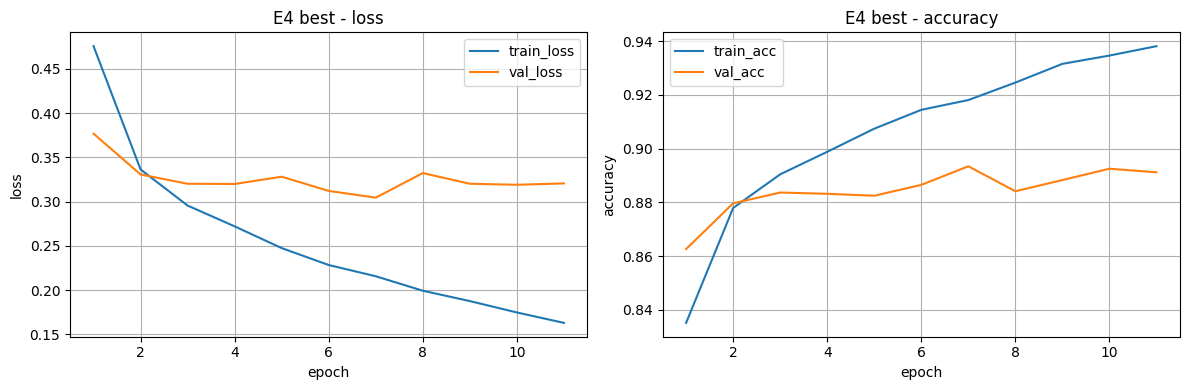

In [8]:
val_e2, val_e3 = runs[1]["best_val_accuracy"], runs[2]["best_val_accuracy"]
use_dropout = val_e2 >= val_e3

print("=== E4: EarlyStopping (best from E2/E3) ===")
set_seed(SEED)
model = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.3 if use_dropout else 0.0,
            use_batchnorm=not use_dropout).to(device)
opt = optim.Adam(model.parameters(), lr=1e-3)
es = EarlyStopping(patience=4)
h4 = fit(model, train_loader, val_loader, opt, criterion, device, MAX_EPOCHS, early_stopping=es)
best_idx = np.argmax(h4["val_acc"])
runs.append({
    "experiment_id": "E4", "dataset": "KMNIST", "seed": SEED,
    "model_summary": f"2 hidden, EarlyStopping, {'Dropout' if use_dropout else 'BatchNorm'}",
    "optimizer": "Adam", "lr": 1e-3, "momentum": 0, "weight_decay": 0,
    "epochs_trained": len(h4["train_loss"]), "best_val_accuracy": h4["val_acc"][best_idx],
    "best_val_loss": h4["val_loss"][best_idx]
})

torch.save(model.state_dict(), os.path.join(ARTIFACTS, 'best_model.pt'))
plot_history(h4, "E4 best", os.path.join(FIGURES, 'curves_best.png'))

## 9. Experiment O1: LR too large

In [9]:
print("=== O1: LR too large ===")
set_seed(SEED)
model_o1 = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.3 if use_dropout else 0.0,
               use_batchnorm=not use_dropout).to(device)
opt_o1 = optim.Adam(model_o1.parameters(), lr=1e-1)
ho1 = fit(model_o1, train_loader, val_loader, opt_o1, criterion, device, 6, None)
runs.append({
    "experiment_id": "O1", "dataset": "KMNIST", "seed": SEED,
    "model_summary": "same as E4", "optimizer": "Adam", "lr": 1e-1, "momentum": 0, "weight_decay": 0,
    "epochs_trained": 6, "best_val_accuracy": max(ho1["val_acc"]), "best_val_loss": min(ho1["val_loss"])
})

=== O1: LR too large ===
epoch 01/6 | train loss=0.5557 acc=0.7968 | val loss=0.4360 acc=0.8436
epoch 02/6 | train loss=0.4288 acc=0.8465 | val loss=0.3770 acc=0.8645
epoch 03/6 | train loss=0.3875 acc=0.8601 | val loss=0.3955 acc=0.8569
epoch 04/6 | train loss=0.3617 acc=0.8679 | val loss=0.4037 acc=0.8546
epoch 05/6 | train loss=0.3477 acc=0.8725 | val loss=0.4187 acc=0.8524
epoch 06/6 | train loss=0.3273 acc=0.8799 | val loss=0.3749 acc=0.8664


## 10. Experiment O2: LR too small

In [10]:
print("=== O2: LR too small ===")
set_seed(SEED)
model_o2 = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.3 if use_dropout else 0.0,
               use_batchnorm=not use_dropout).to(device)
opt_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)
ho2 = fit(model_o2, train_loader, val_loader, opt_o2, criterion, device, 6, None)
runs.append({
    "experiment_id": "O2", "dataset": "KMNIST", "seed": SEED,
    "model_summary": "same as E4", "optimizer": "Adam", "lr": 1e-5, "momentum": 0, "weight_decay": 0,
    "epochs_trained": 6, "best_val_accuracy": max(ho2["val_acc"]), "best_val_loss": min(ho2["val_loss"])
})

=== O2: LR too small ===
epoch 01/6 | train loss=1.5537 acc=0.5562 | val loss=1.1497 acc=0.7409
epoch 02/6 | train loss=1.0271 acc=0.7605 | val loss=0.9111 acc=0.7791
epoch 03/6 | train loss=0.8524 acc=0.7897 | val loss=0.7893 acc=0.7989
epoch 04/6 | train loss=0.7481 acc=0.8083 | val loss=0.7061 acc=0.8167
epoch 05/6 | train loss=0.6774 acc=0.8208 | val loss=0.6462 acc=0.8266
epoch 06/6 | train loss=0.6235 acc=0.8298 | val loss=0.6009 acc=0.8333


## 11. Experiment O3: SGD + momentum + weight decay

In [11]:
print("=== O3: SGD + momentum + weight decay ===")
set_seed(SEED)
model_o3 = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.3 if use_dropout else 0.0,
               use_batchnorm=not use_dropout).to(device)
opt_o3 = optim.SGD(model_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4)
ho3 = fit(model_o3, train_loader, val_loader, opt_o3, criterion, device, 12, None)
runs.append({
    "experiment_id": "O3", "dataset": "KMNIST", "seed": SEED,
    "model_summary": "same as E4", "optimizer": "SGD", "lr": 1e-2, "momentum": 0.9, "weight_decay": 1e-4,
    "epochs_trained": 12, "best_val_accuracy": max(ho3["val_acc"]), "best_val_loss": min(ho3["val_loss"])
})

=== O3: SGD + momentum + weight decay ===
epoch 01/12 | train loss=0.4980 acc=0.8253 | val loss=0.3878 acc=0.8600
epoch 02/12 | train loss=0.3433 acc=0.8763 | val loss=0.3423 acc=0.8760
epoch 03/12 | train loss=0.3013 acc=0.8896 | val loss=0.3189 acc=0.8859
epoch 04/12 | train loss=0.2772 acc=0.8987 | val loss=0.3299 acc=0.8795
epoch 05/12 | train loss=0.2566 acc=0.9040 | val loss=0.3245 acc=0.8833
epoch 06/12 | train loss=0.2367 acc=0.9122 | val loss=0.3116 acc=0.8856
epoch 07/12 | train loss=0.2241 acc=0.9160 | val loss=0.3103 acc=0.8904
epoch 08/12 | train loss=0.2102 acc=0.9221 | val loss=0.3144 acc=0.8896
epoch 09/12 | train loss=0.1988 acc=0.9273 | val loss=0.3108 acc=0.8887
epoch 10/12 | train loss=0.1869 acc=0.9313 | val loss=0.3250 acc=0.8877
epoch 11/12 | train loss=0.1754 acc=0.9360 | val loss=0.3309 acc=0.8813
epoch 12/12 | train loss=0.1681 acc=0.9380 | val loss=0.3152 acc=0.8917


## 12. Save artifacts and final test

In [12]:
best_config = {
    "dataset": "KMNIST", "seed": SEED, "hidden_dims": list(HIDDEN_DIMS),
    "dropout": 0.3 if use_dropout else 0.0, "use_batchnorm": not use_dropout,
    "optimizer": "Adam", "lr": 1e-3, "best_val_accuracy": runs[-1]["best_val_accuracy"],
}

with open(os.path.join(ARTIFACTS, 'best_config.json'), 'w') as f:
    json.dump(best_config, f, indent=2)

with open(os.path.join(ARTIFACTS, 'runs.csv'), 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=runs[0].keys())
    w.writeheader()
    w.writerows(runs)

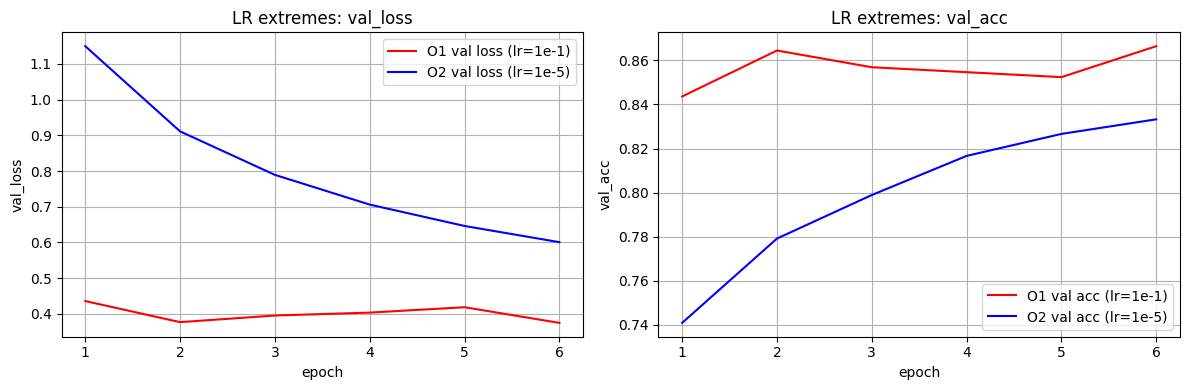

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_o1 = np.arange(1, len(ho1["val_loss"]) + 1)
epochs_o2 = np.arange(1, len(ho2["val_loss"]) + 1)
axes[0].plot(epochs_o1, ho1["val_loss"], 'r-', label="O1 val loss (lr=1e-1)")
axes[0].plot(epochs_o2, ho2["val_loss"], 'b-', label="O2 val loss (lr=1e-5)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("val_loss")
axes[0].set_title("LR extremes: val_loss")
axes[0].legend()
axes[0].grid(True)
axes[1].plot(epochs_o1, ho1["val_acc"], 'r-', label="O1 val acc (lr=1e-1)")
axes[1].plot(epochs_o2, ho2["val_acc"], 'b-', label="O2 val acc (lr=1e-5)")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("val_acc")
axes[1].set_title("LR extremes: val_acc")
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'curves_lr_extremes.png'), dpi=100, bbox_inches='tight')
plt.show()

In [14]:
set_seed(SEED)
model = MLP(INPUT_DIM, HIDDEN_DIMS, NUM_CLASSES, dropout_p=0.3 if use_dropout else 0.0,
            use_batchnorm=not use_dropout).to(device)
model.load_state_dict(torch.load(os.path.join(ARTIFACTS, 'best_model.pt'), map_location=device))
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"Final test accuracy (E4): {test_acc:.4f}")

best_config["test_accuracy"] = test_acc
with open(os.path.join(ARTIFACTS, 'best_config.json'), 'w') as f:
    json.dump(best_config, f, indent=2)

print("Done. Artifacts saved to", ARTIFACTS)

Final test accuracy (E4): 0.8836
Done. Artifacts saved to artifacts
